# Week 8 — K-Nearest Neighbors and Distance Metrics

**Dataset:** Marketing and Product Performance (synthetic; 10,000 campaigns)  
**Week 8 objective:** Apply K-nearest neighbors (KNN) to the project dataset, compare distance metrics, and evaluate whether the available campaign attributes support reliable classification of observed revenue performance.

This notebook is a self-contained Week 8 submission. It documents the modeling choices, evaluation evidence, and conclusions needed for the Milestone Two appendix.

## Week 8 focus

This analysis applies the Week 8 material directly to the project dataset:

- KNN classification using a balanced high-/lower-revenue outcome
- Euclidean, Manhattan, Minkowski, and cosine distance metrics
- Feature scaling and the effect of outliers on distance-based models
- Hyperparameter tuning for neighborhood size and Minkowski `p`
- Held-out evaluation, baseline comparison, and overfitting assessment

The purpose is to test model feasibility honestly. A high score must generalize to unseen campaigns; a near-baseline score is still a meaningful finding when supported by validation evidence.

In [ ]:
# Standard-library configuration
import warnings

# Data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# K-nearest-neighbor modeling and evaluation tools
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
RANDOM_STATE = 42

# Load the selected marketing and product performance dataset.
DATA_PATH = 'marketing_and_product_performance.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape[0]:,} campaigns × {df.shape[1]} columns')
display(df.head())


Dataset shape: 10,000 campaigns × 17 columns


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


## 2. Data-quality and EDA checks

KNN is distance-based: a feature with a much larger numerical range can dominate the notion of similarity. Before modeling, I check completeness, scale differences, class balance, and relationships with revenue. These checks directly motivate the preprocessing pipeline used later.

In [2]:
# Audit data types, completeness, and feature cardinality.
quality = pd.DataFrame(
    {
        'data_type': df.dtypes.astype(str),
        'missing_values': df.isna().sum(),
        'unique_values': df.nunique(),
    }
)
display(quality)

# Define a balanced classification target using the dataset median.
revenue_median = df['Revenue_Generated'].median()
df['High_Revenue'] = (df['Revenue_Generated'] >= revenue_median).astype(int)

class_counts = (
    df['High_Revenue']
    .value_counts()
    .sort_index()
    .rename(index={0: 'Lower revenue', 1: 'High revenue'})
)

print(f'Median revenue threshold: ${revenue_median:,.2f}')
print('Class counts:')
display(class_counts.to_frame('campaigns'))


,data_type,missing_values,unique_values
Campaign_ID,str,0,10000
Product_ID,str,0,10000
Budget,float64,0,9995
Clicks,int64,0,4298
Conversions,int64,0,999
Revenue_Generated,float64,0,9997
ROI,float64,0,451
Customer_ID,str,0,10000
Subscription_Tier,str,0,3
Subscription_Length,int64,0,35


Median revenue threshold: $49,513.82
Class counts:


,campaigns
High_Revenue,
Lower revenue,5000
High revenue,5000


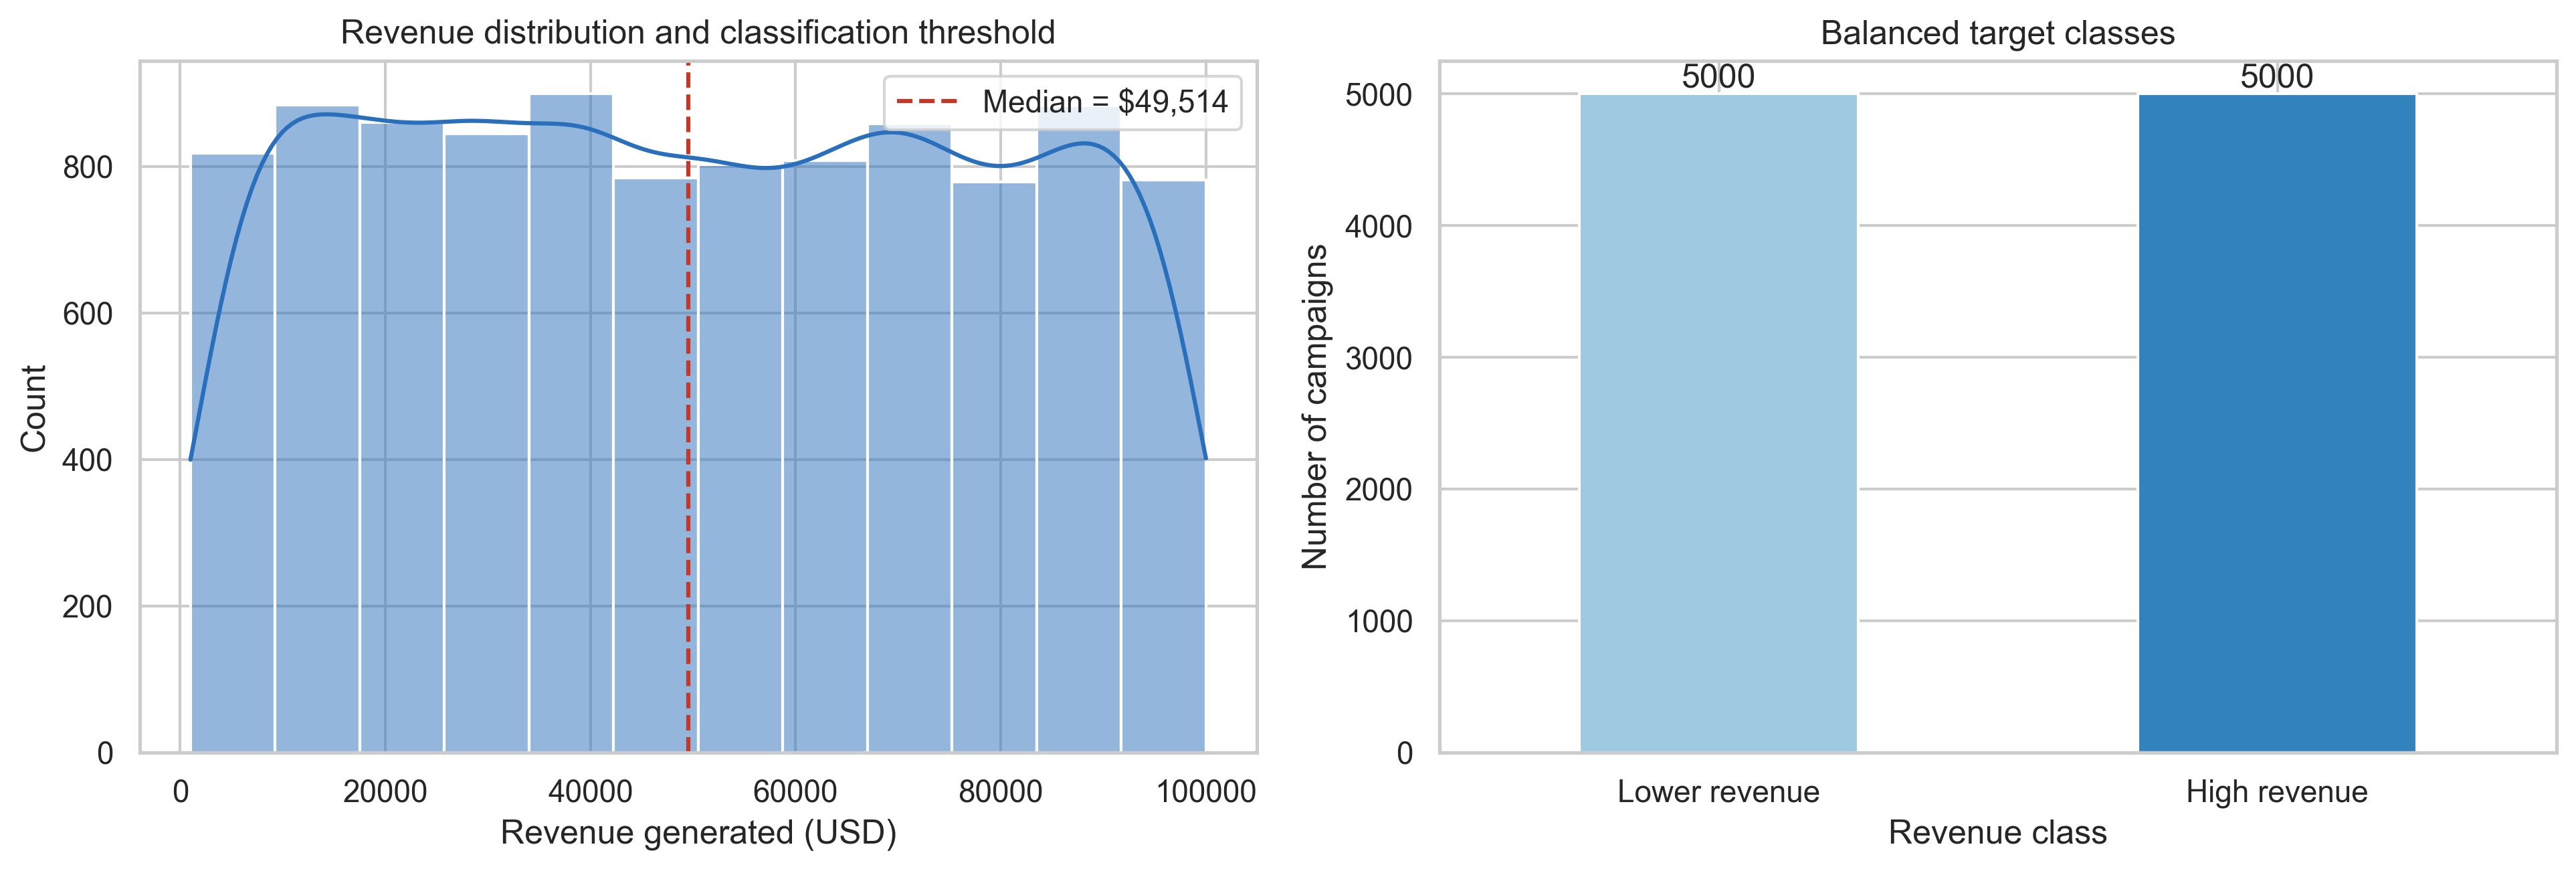

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df, x='Revenue_Generated', bins=12, kde=True, color='#2a6fbb', ax=axes[0])
axes[0].axvline(revenue_median, color='#c0392b', linestyle='--', label=f'Median = ${revenue_median:,.0f}')
axes[0].set_title('Revenue distribution and classification threshold')
axes[0].set_xlabel('Revenue generated (USD)')
axes[0].legend()

class_counts.plot(kind='bar', color=['#9ecae1', '#3182bd'], ax=axes[1])
axes[1].set_title('Balanced target classes')
axes[1].set_xlabel('Revenue class')
axes[1].set_ylabel('Number of campaigns')
axes[1].tick_params(axis='x', rotation=0)
for container in axes[1].containers:
    axes[1].bar_label(container)
plt.tight_layout()
plt.show()

In [4]:
numeric_features_all = df.drop(columns=['High_Revenue']).select_dtypes(include=np.number).columns.tolist()
scale_summary = df[numeric_features_all].describe().T[['min', 'max', 'mean', 'std']]
scale_summary['range'] = scale_summary['max'] - scale_summary['min']
display(scale_summary.sort_values('range', ascending=False).style.format('{:,.2f}'))

corr = df.select_dtypes(include=np.number).corr(numeric_only=True)['Revenue_Generated'].drop('Revenue_Generated').sort_values()
print('Correlation is descriptive only; it does not establish causation or feature timing.')
display(corr.to_frame('correlation_with_revenue').style.format('{:.3f}'))

,min,max,mean,std,range
Revenue_Generated,"1,002.08","99,999.47","50,038.63","28,545.70","98,997.39"
Budget,500.44,"49,999.63","25,263.61","14,350.09","49,499.19"
Clicks,10.00,"4,999.00","2,481.90","1,435.97","4,989.00"
Conversions,1.00,999.00,498.98,289.48,998.00
Bundle_Price,50.01,499.97,275.20,129.22,449.96
Units_Sold,1.00,199.00,100.69,57.07,198.00
Discount_Level,10.00,69.00,39.42,17.21,59.00
Subscription_Length,1.00,35.00,18.02,10.15,34.00
ROI,0.50,5.00,2.76,1.30,4.50
Customer_Satisfaction_Post_Refund,1.00,4.00,2.50,1.11,3.00


Correlation is descriptive only; it does not establish causation or feature timing.


,correlation_with_revenue
Budget,-0.021
Clicks,-0.007
Bundle_Price,-0.004
Customer_Satisfaction_Post_Refund,-0.003
Discount_Level,0.002
Conversions,0.003
Subscription_Length,0.005
ROI,0.008
Units_Sold,0.009
High_Revenue,0.868


**EDA interpretation.** The numeric features have very different ranges (for example, dollar budgets versus binary sale flags), so unscaled KNN would make large-scale variables disproportionately influential. The correlation table provides a descriptive check of the available numeric variables. These variables may be useful for describing completed campaigns, but their timing is not documented; the exercise should not be presented as a pre-launch causal or forecasting system.

## 3. KNN concepts applied here

KNN stores the training examples and labels a new campaign according to its nearest labeled campaigns. In classification, the default prediction is a majority vote; distance weighting lets nearer campaigns vote more strongly. The following distances were compared:

- **Euclidean (L2):** straight-line distance; squared differences make a large deviation influential.
- **Manhattan (L1):** sum of absolute differences; less sensitive to one unusually large feature difference.
- **Minkowski:** a tunable generalization. `p=1` is Manhattan and `p=2` is Euclidean; larger `p` increasingly emphasizes the largest coordinate gap.
- **Cosine:** compares vector direction rather than magnitude. It can be useful when the proportions among features matter more than total scale.

The model uses a pipeline so `StandardScaler` is fitted within each cross-validation fold, preventing information from validation or test records from entering the training transformation.

In [5]:
identifier_columns = ['Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID']
X = df.drop(columns=identifier_columns + ['Revenue_Generated', 'High_Revenue'])
y = df['High_Revenue']

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ],
    remainder='drop'
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f'Training set: {X_train.shape[0]} campaigns; untouched test set: {X_test.shape[0]} campaigns')

Numeric features: ['Budget', 'Clicks', 'Conversions', 'ROI', 'Subscription_Length', 'Discount_Level', 'Units_Sold', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund']
Categorical features: ['Subscription_Tier', 'Common_Keywords']
Training set: 8000 campaigns; untouched test set: 2000 campaigns


## 4. Hyperparameter tuning and distance-metric comparison

The search evaluates odd values of **k** = 5, 15, and 31, avoiding tied votes in this balanced binary problem. Uniform voting is held constant so the comparison isolates the effect of distance geometry and neighborhood size. Euclidean, Manhattan, Minkowski, and cosine distance are all evaluated. For Minkowski, `p ∈ {1.5, 3}` is searched; scikit-learn requires `p ≥ 1` for this metric.

A very small `k` can memorize local noise, while a very large `k` oversmooths meaningful local patterns. Five-fold stratified cross-validation estimates generalization within the training set and guides the choice before the holdout test is viewed.

In [6]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier(weights='uniform'))
])

# A focused search across all required metrics.  Uniform voting is held constant so
# the comparison isolates distance geometry and neighborhood size.
param_grid = [
    {'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [5, 15, 31]},
    {'knn__metric': ['minkowski'], 'knn__p': [1.5, 3], 'knn__n_neighbors': [15]},
    {'knn__metric': ['cosine'], 'knn__algorithm': ['brute'], 'knn__n_neighbors': [15]},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=1,
    return_train_score=True
)
search.fit(X_train, y_train)

results = pd.DataFrame(search.cv_results_)
results['metric'] = results['param_knn__metric'].astype(str)
results['k'] = results['param_knn__n_neighbors'].astype(int)
results['weights'] = 'uniform'
results['p'] = results['param_knn__p'].astype(str).replace('nan', '—')
summary_columns = ['metric', 'p', 'k', 'weights', 'mean_test_score', 'std_test_score', 'mean_train_score']
results_display = results[summary_columns].sort_values(['mean_test_score', 'std_test_score'], ascending=[False, True])
print('Best cross-validated configuration:', search.best_params_)
print(f'Best mean validation F1: {search.best_score_:.3f}')
display(results_display.style.format({
    'mean_test_score': '{:.3f}', 'std_test_score': '{:.3f}', 'mean_train_score': '{:.3f}'
}))

Best cross-validated configuration: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5}
Best mean validation F1: 0.512


,metric,p,k,weights,mean_test_score,std_test_score,mean_train_score
0,euclidean,nan,5,uniform,0.512,0.002,0.693
3,manhattan,nan,5,uniform,0.512,0.007,0.695
7,minkowski,3.0,15,uniform,0.507,0.013,0.602
5,manhattan,nan,31,uniform,0.504,0.007,0.580
6,minkowski,1.5,15,uniform,0.503,0.008,0.606
2,euclidean,nan,31,uniform,0.502,0.006,0.579
1,euclidean,nan,15,uniform,0.501,0.006,0.602
8,cosine,nan,15,uniform,0.499,0.008,0.604
4,manhattan,nan,15,uniform,0.498,0.011,0.606


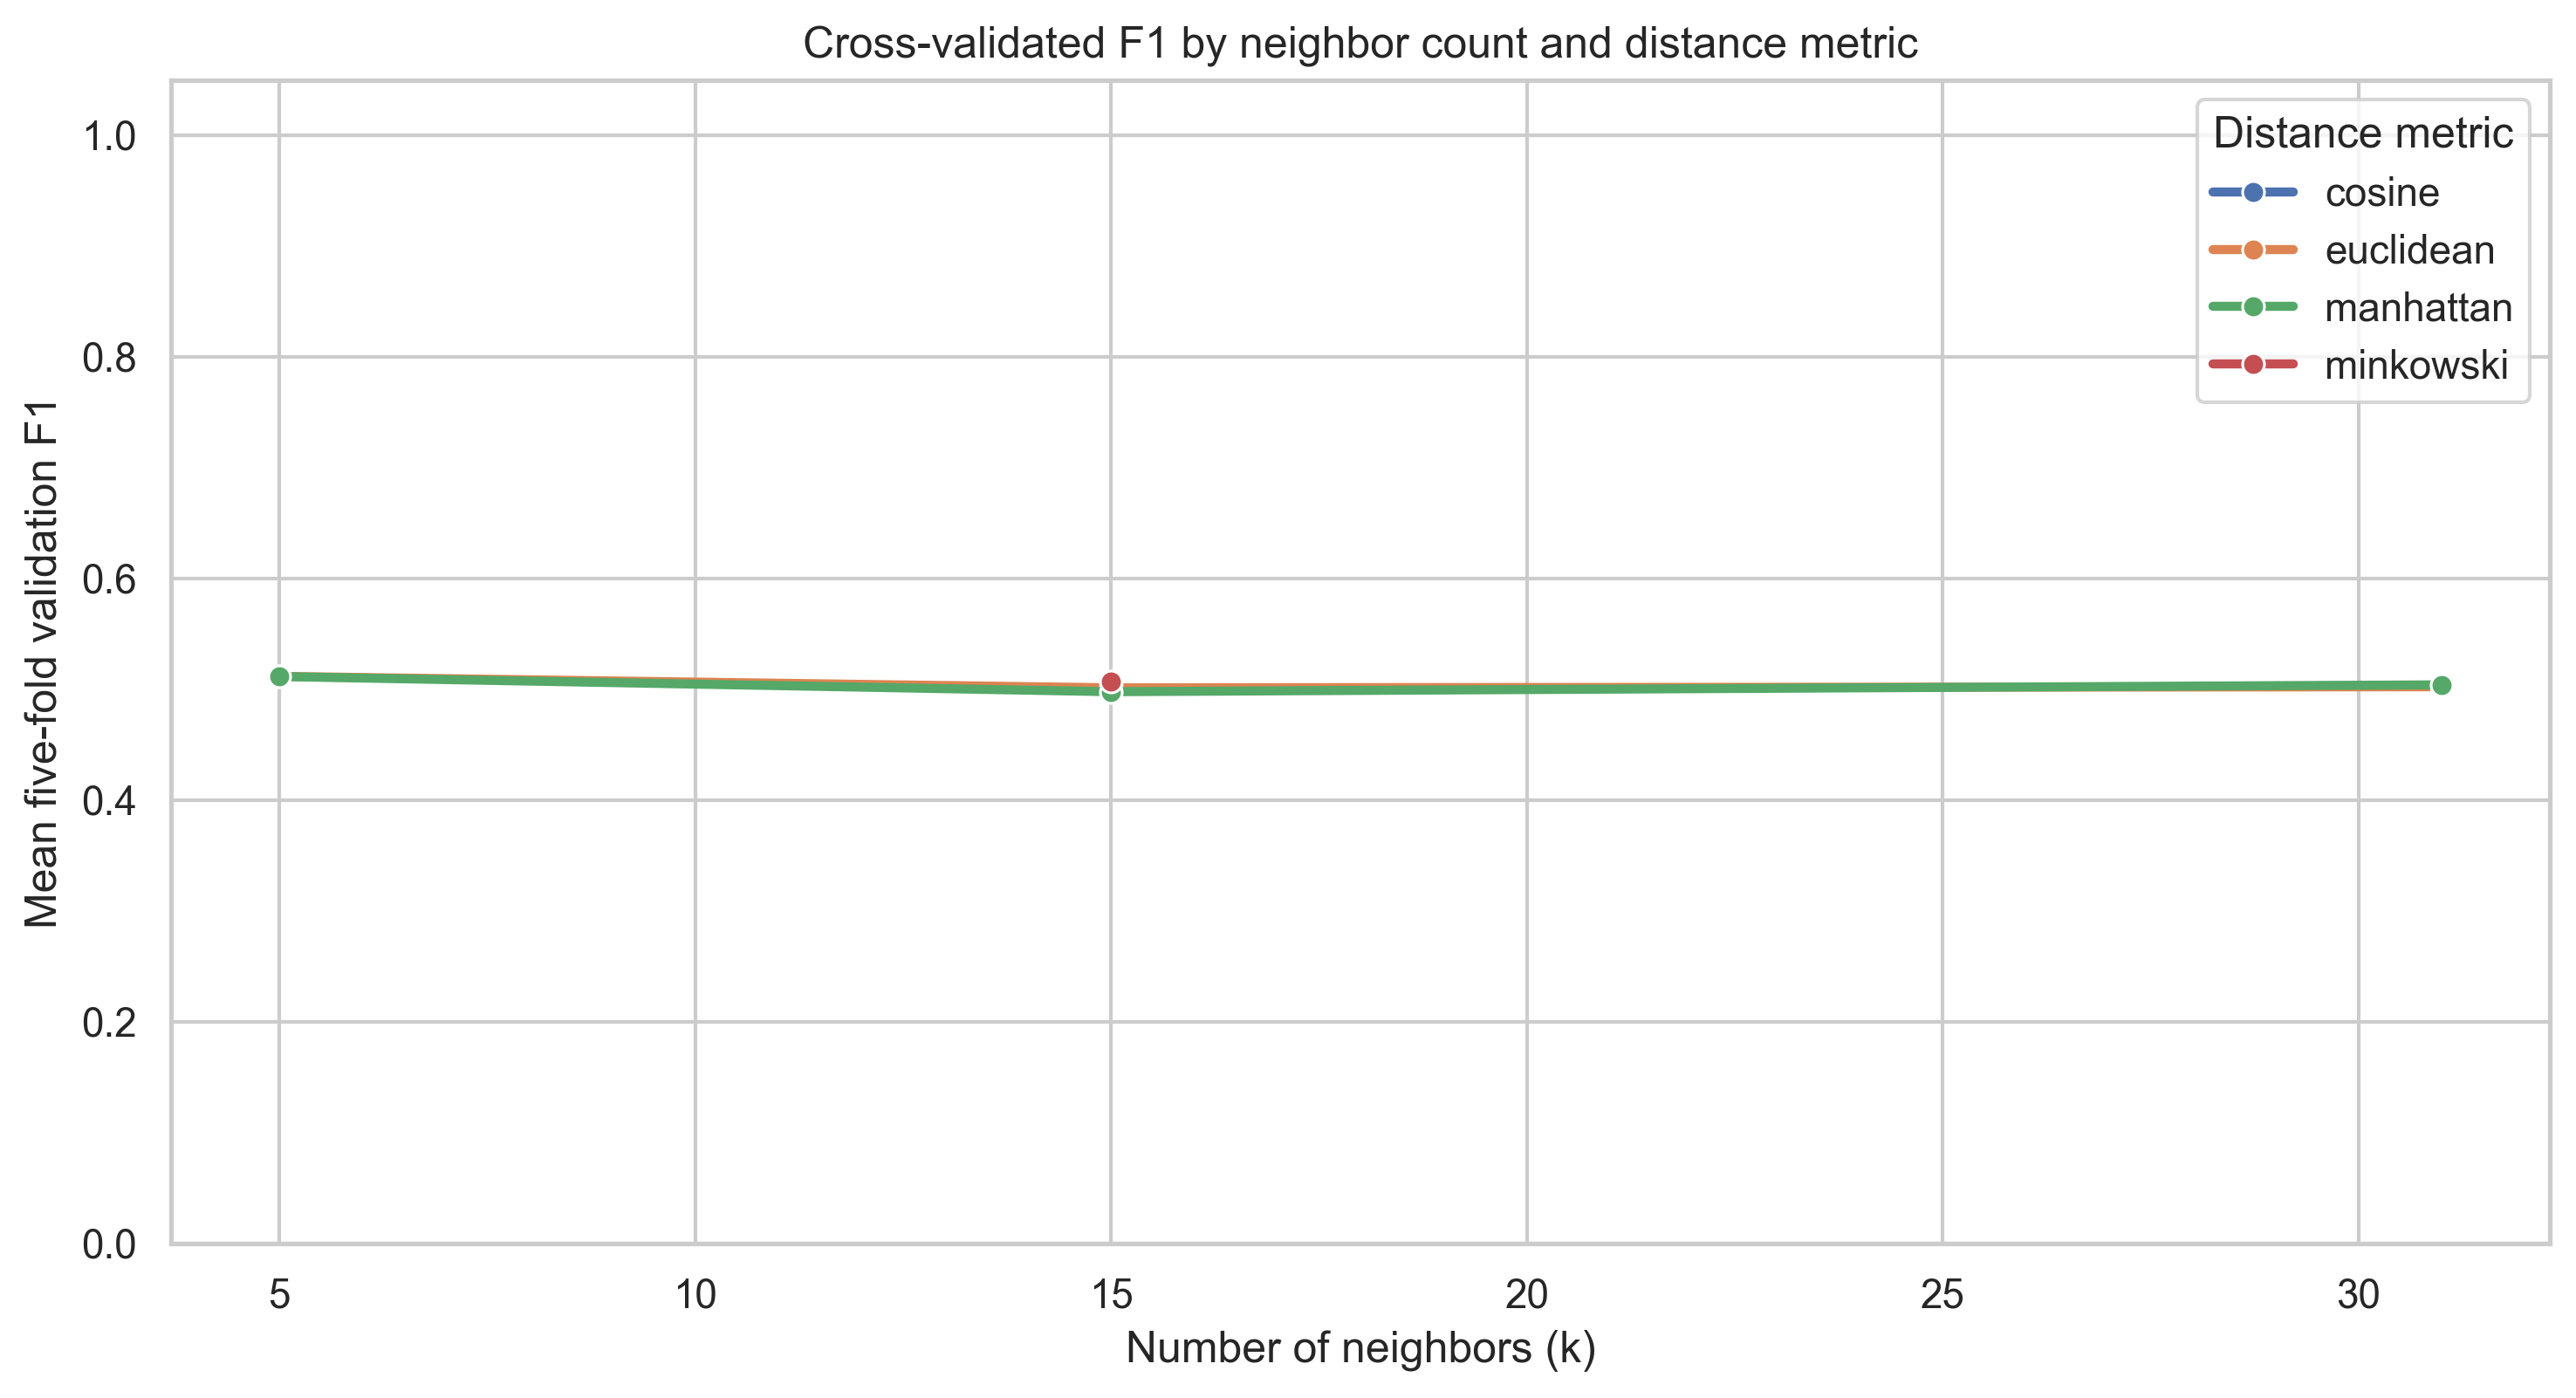

,metric,p,k,weights,mean_test_score,std_test_score,mean_train_score
1,euclidean,nan,5,uniform,0.512,0.002,0.693
2,manhattan,nan,5,uniform,0.512,0.007,0.695
3,minkowski,3.0,15,uniform,0.507,0.013,0.602
0,cosine,nan,15,uniform,0.499,0.008,0.604


In [7]:
# For a readable metric comparison, retain each metric's strongest configuration at each k.
best_by_metric_k = (results.sort_values('mean_test_score', ascending=False)
                    .groupby(['metric', 'k'], as_index=False)
                    .first())

plt.figure(figsize=(10, 5.5))
sns.lineplot(data=best_by_metric_k, x='k', y='mean_test_score', hue='metric', marker='o', linewidth=2.5)
plt.ylim(0, 1.05)
plt.title('Cross-validated F1 by neighbor count and distance metric')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Mean five-fold validation F1')
plt.legend(title='Distance metric')
plt.tight_layout()
plt.show()

metric_best = (results_display.sort_values('mean_test_score', ascending=False)
               .groupby('metric', as_index=False).first()
               .sort_values('mean_test_score', ascending=False))
display(metric_best.style.format({'mean_test_score': '{:.3f}', 'std_test_score': '{:.3f}', 'mean_train_score': '{:.3f}'}))

## 5. Held-out evaluation and overfitting check

The test set below has not influenced the parameter search. I compare the tuned KNN model with a majority-class baseline and report accuracy, precision, recall, F1, and ROC AUC. F1 remains the main metric because it balances precision and recall; the other metrics make the nature of errors transparent.

Overfitting is assessed by comparing cross-validated training and validation F1, then comparing the selected model's validation estimate with its one-time test result. This does not eliminate uncertainty—2,000 test campaigns is a small test set—but it is stronger evidence than a training score alone.

In [8]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

baseline = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

model_metrics = pd.DataFrame({
    'Model': ['Majority-class baseline', 'Tuned KNN'],
    'Accuracy': [accuracy_score(y_test, baseline_pred), accuracy_score(y_test, y_pred)],
    'Precision': [precision_score(y_test, baseline_pred, zero_division=0), precision_score(y_test, y_pred, zero_division=0)],
    'Recall': [recall_score(y_test, baseline_pred, zero_division=0), recall_score(y_test, y_pred, zero_division=0)],
    'F1': [f1_score(y_test, baseline_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)],
    'ROC AUC': [np.nan, roc_auc_score(y_test, y_prob)],
})
display(model_metrics.style.format({c: '{:.3f}' for c in model_metrics.columns[1:]}))

cv_train = results.loc[search.best_index_, 'mean_train_score']
cv_valid = results.loc[search.best_index_, 'mean_test_score']
print(f'Best-model mean CV training F1:   {cv_train:.3f}')
print(f'Best-model mean CV validation F1: {cv_valid:.3f}')
print(f'Held-out test F1:                 {f1_score(y_test, y_pred):.3f}')

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Majority-class baseline,0.500,0.000,0.000,0.000,nan
1,Tuned KNN,0.499,0.499,0.495,0.497,0.507


Best-model mean CV training F1:   0.693
Best-model mean CV validation F1: 0.512
Held-out test F1:                 0.497


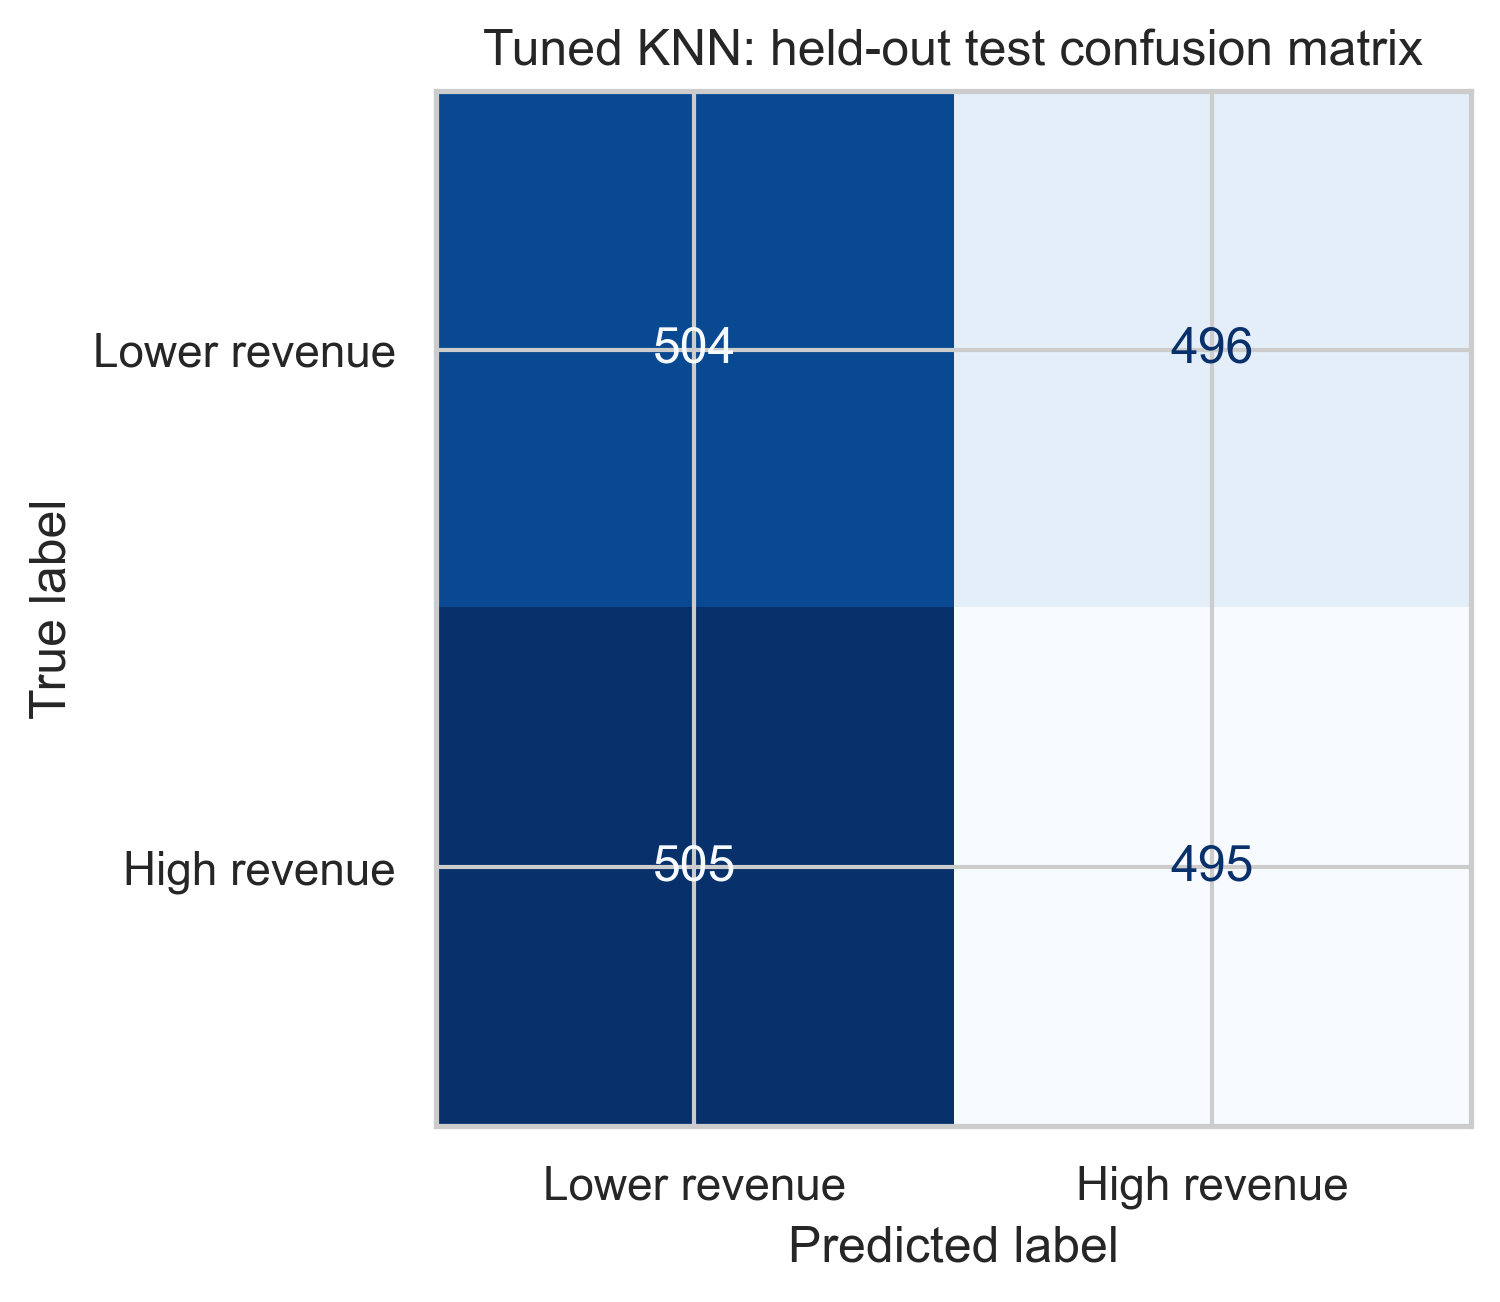

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['Lower revenue', 'High revenue']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Tuned KNN: held-out test confusion matrix')
plt.tight_layout()
plt.show()

**Result interpretation.** The selected Euclidean model (`k=5`, uniform voting) achieved mean five-fold validation F1 = **0.512** and held-out test F1 = **0.497**. Its held-out accuracy was **0.499** and ROC AUC was **0.507**, essentially chance-level for this balanced target. The majority-class baseline also makes clear why accuracy alone is insufficient: it achieves 0.500 accuracy but no ability to identify high-revenue campaigns (F1 = 0). KNN's precision and recall were both about 0.50, so it did not provide a practically meaningful separation of the two revenue groups.

**Overfitting safeguards and evidence.** The training F1 (0.693) was materially higher than validation F1 (0.512), a signal that local patterns learned from the training set did not generalize. Safeguards were: (1) an untouched stratified test set; (2) stratified five-fold CV for hyperparameter selection; (3) preprocessing inside the pipeline so scaling is learned separately within each fold; (4) a bounded, interpretable `k` search; and (5) a baseline comparison. With 10,000 records, the near-chance held-out result is substantive evidence that these available campaign attributes contain little usable KNN signal for this median-revenue classification definition.

## 6. Why scaling matters

The following controlled comparison uses the best Euclidean KNN configuration selected above, once with the fitted `StandardScaler` pipeline and once without numeric scaling. It is a diagnostic, not a second source of model selection: it illustrates how the distance geometry changes when raw units are allowed to dominate.

In [10]:
best_euclidean = results[results['metric'].eq('euclidean')].sort_values('mean_test_score', ascending=False).iloc[0]
euc_k = int(best_euclidean['k'])
euc_weights = str(best_euclidean['weights'])

unscaled_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', 'passthrough', numeric_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)
scaled_euclidean = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=euc_k, metric='euclidean', weights=euc_weights))
]).fit(X_train, y_train)
unscaled_euclidean = Pipeline([
    ('preprocessor', unscaled_preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=euc_k, metric='euclidean', weights=euc_weights))
]).fit(X_train, y_train)

scaling_comparison = pd.DataFrame({
    'Preprocessing': ['StandardScaler + one-hot encoding', 'Raw numeric values + one-hot encoding'],
    'Held-out F1': [f1_score(y_test, scaled_euclidean.predict(X_test)), f1_score(y_test, unscaled_euclidean.predict(X_test))],
    'Held-out accuracy': [accuracy_score(y_test, scaled_euclidean.predict(X_test)), accuracy_score(y_test, unscaled_euclidean.predict(X_test))],
})
print(f'Euclidean comparison uses k={euc_k}, weights={euc_weights}.')
display(scaling_comparison.style.format({'Held-out F1': '{:.3f}', 'Held-out accuracy': '{:.3f}'}))

Euclidean comparison uses k=5, weights=uniform.


,Preprocessing,Held-out F1,Held-out accuracy
0,StandardScaler + one-hot encoding,0.497,0.499
1,Raw numeric values + one-hot encoding,0.503,0.513


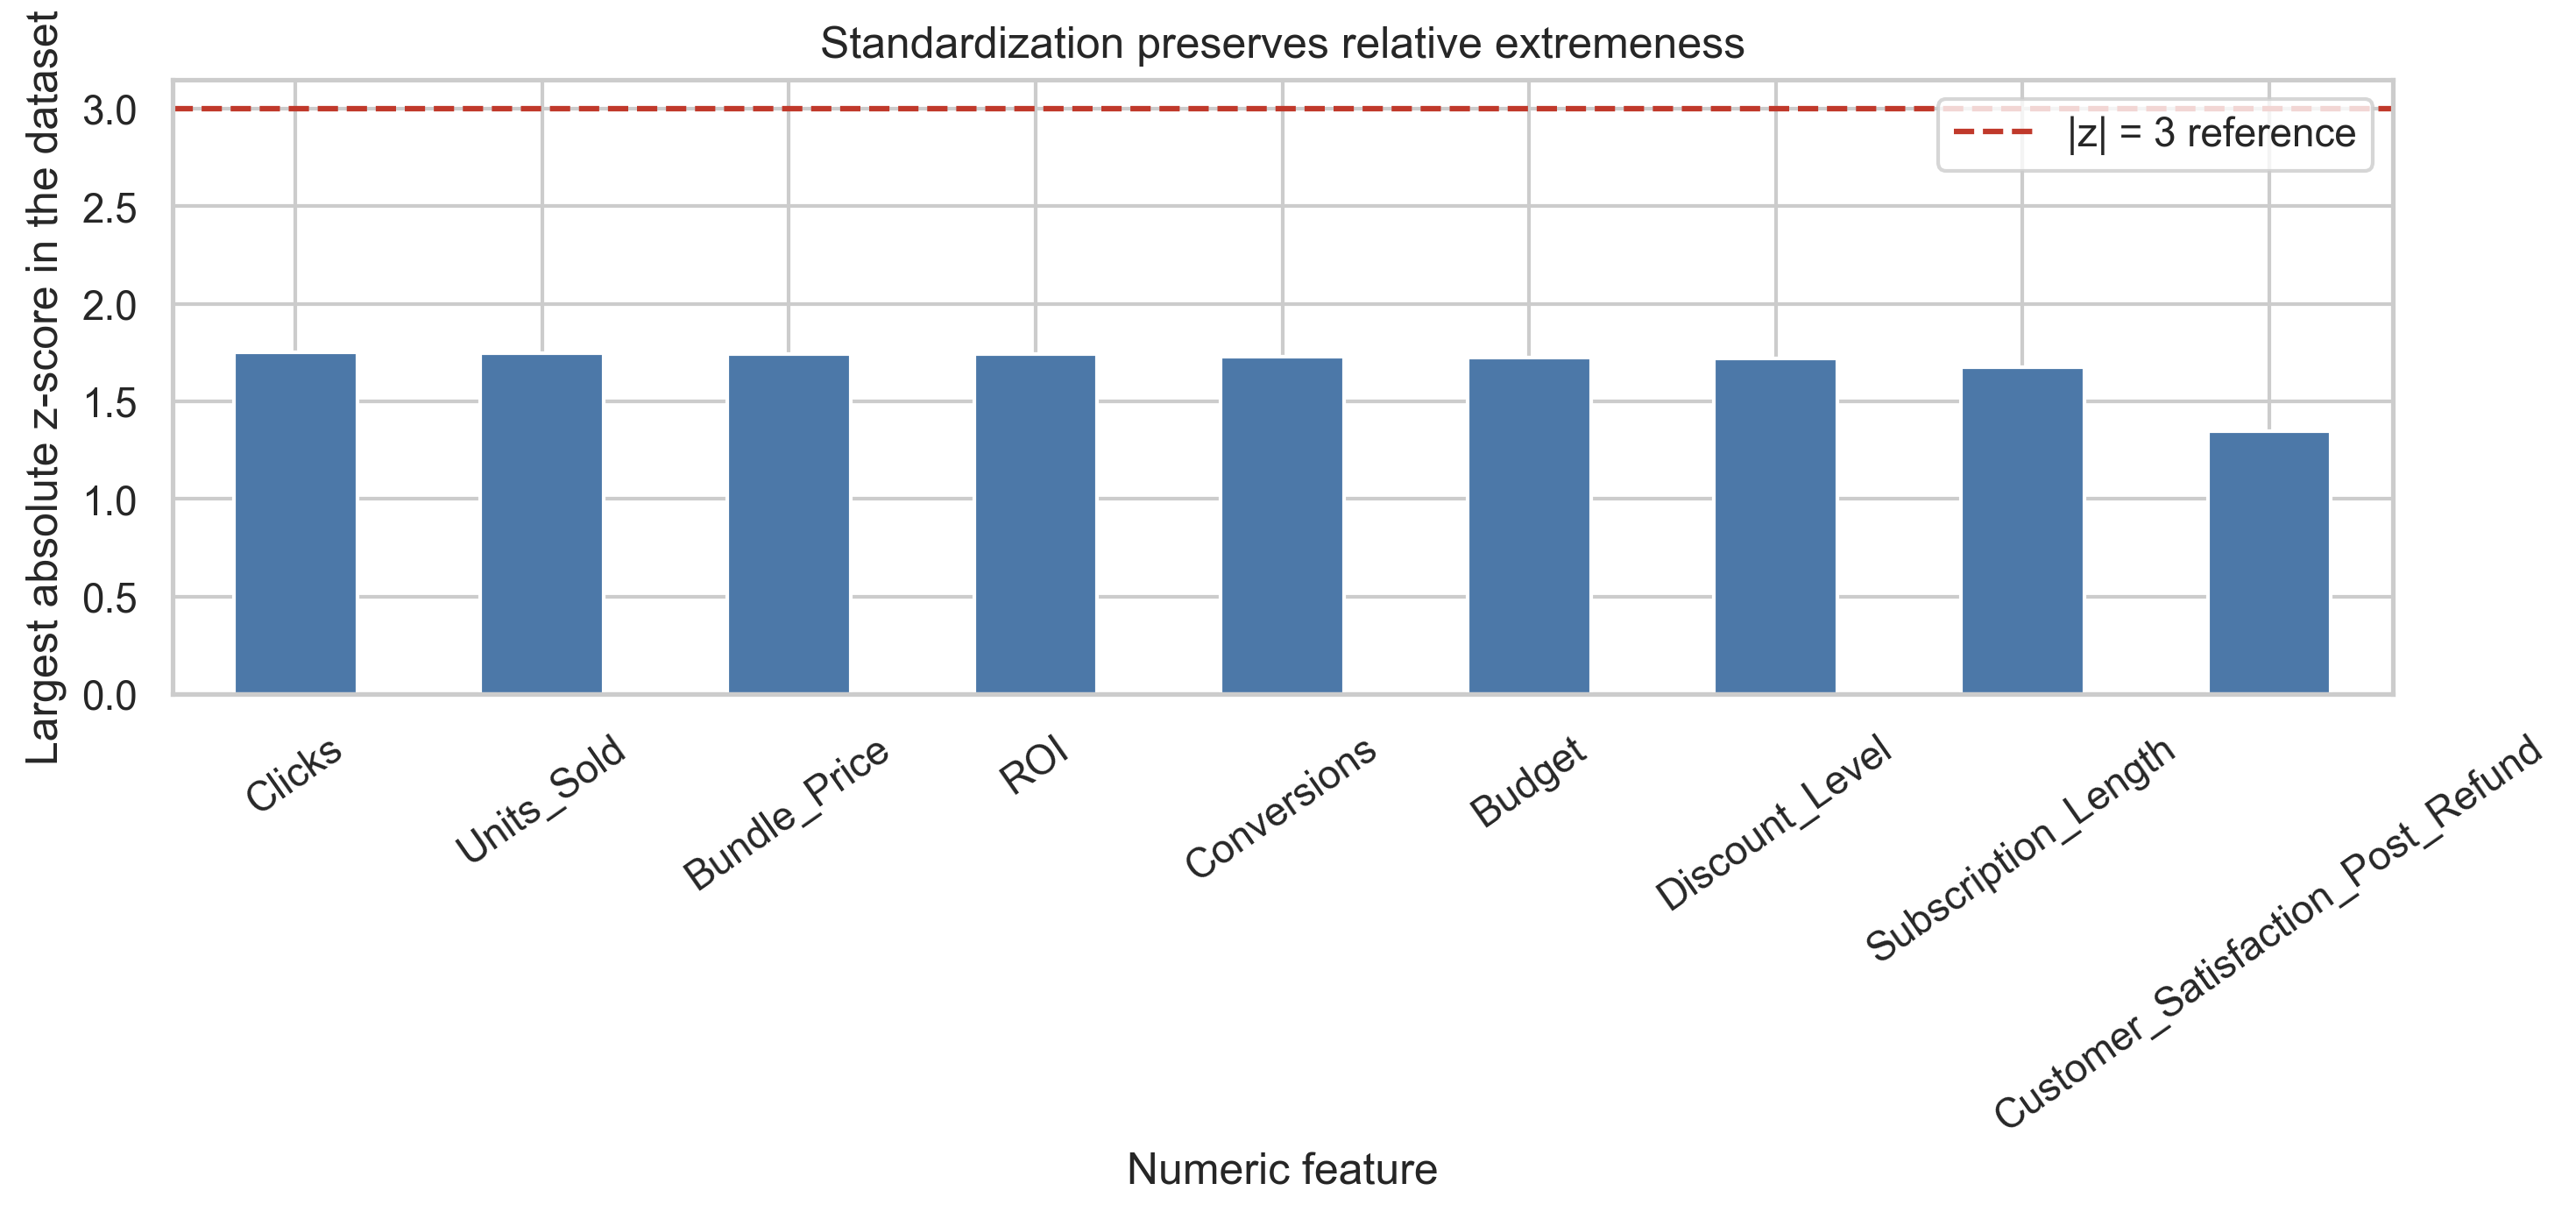

No observed feature exceeds |z| = 3 in this 10,000-campaign sample. Scaling equalizes units; it does not delete unusual records.


In [11]:
numeric_z = pd.DataFrame(StandardScaler().fit_transform(df[numeric_features]), columns=numeric_features)
max_abs_z = numeric_z.abs().max().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.8))
max_abs_z.plot(kind='bar', color='#4c78a8', ax=ax)
ax.axhline(3, color='#c0392b', linestyle='--', label='|z| = 3 reference')
ax.set_title('Standardization preserves relative extremeness')
ax.set_ylabel('Largest absolute z-score in the dataset')
ax.set_xlabel('Numeric feature')
ax.tick_params(axis='x', rotation=35)
ax.legend()
plt.tight_layout()
plt.show()

print('No observed feature exceeds |z| = 3 in this 10,000-campaign sample. Scaling equalizes units; it does not delete unusual records.')

## 7. Course “Think About It” questions

### 7.1 Why use Manhattan distance when outliers are possible?

Manhattan distance adds absolute differences, whereas Euclidean distance squares them before adding. A large one-feature difference therefore receives much more influence under Euclidean distance. If an otherwise comparable campaign has one unusual recorded value, Manhattan distance can keep that single feature from dominating neighbor selection. This is not a license to ignore data-quality issues: an outlier should still be investigated.

### 7.2 What does Minkowski distance approach as *p* becomes very large?

It approaches the **Chebyshev distance**, `max(|xᵢ − yᵢ|)`: the largest coordinate difference dominates. The numerical example below demonstrates the convergence. Values such as 1,000,000 can overflow in ordinary arithmetic, so the calculation uses a stable rescaling identity.

In [12]:
def stable_minkowski(delta, p):
    """Numerically stable Minkowski norm for a vector of coordinate differences."""
    delta = np.abs(np.asarray(delta, dtype=float))
    scale = delta.max()
    return scale * np.sum((delta / scale) ** p) ** (1 / p)

delta = np.array([2.0, 5.0])
p_values = [1, 2, 5, 10, 100, 1_000_000]
minkowski_demo = pd.DataFrame({
    'p': p_values,
    'Minkowski distance for differences (2, 5)': [stable_minkowski(delta, p) for p in p_values]
})
display(minkowski_demo.style.format({'Minkowski distance for differences (2, 5)': '{:.6f}'}))
print(f'Chebyshev (maximum-coordinate) distance: {delta.max():.6f}')

,p,"Minkowski distance for differences (2, 5)"
0,1,7.000000
1,2,5.385165
2,5,5.010198
3,10,5.000052
4,100,5.000000
5,1000000,5.000000


Chebyshev (maximum-coordinate) distance: 5.000000


### 7.3 Does standardization remove outliers?

No. Standardization transforms a value to its number of standard deviations from the mean; it does not discard or cap it. The order of values is preserved. In the illustrative vector below, the unusually large final observation remains the largest and has a large positive z-score after standardization. In this particular campaign dataset, no numeric value crosses the conventional `|z| = 3` reference, but that empirical result does not change the general principle.

### 7.4 Why choose cosine distance for documents or other directional data?

Cosine distance compares the angle between feature vectors. Two documents with the same word proportions but different lengths point in the same direction and have cosine distance near zero. Likewise, it can be useful when a campaign *profile* or mix matters more than its total magnitude. In this dataset, magnitude may itself be meaningful, so cosine is treated as a candidate to test rather than an assumed best choice.

In [13]:
illustration = np.array([1, 1, 1, 1, 1, 100], dtype=float)
illustration_z = StandardScaler().fit_transform(illustration.reshape(-1, 1)).ravel()
proof = pd.DataFrame({'original_value': illustration, 'z_score': illustration_z})
display(proof.style.format({'z_score': '{:.3f}'}))
print('The observation 100 remains the largest observation and remains far from the center after standardization.')

vector_a = np.array([2, 1])
vector_b = np.array([4, 2])
cosine_similarity = np.dot(vector_a, vector_b) / (np.linalg.norm(vector_a) * np.linalg.norm(vector_b))
print(f'Cosine distance between [2, 1] and [4, 2]: {1 - cosine_similarity:.6f}')

,original_value,z_score
0,1.000000,-0.447
1,1.000000,-0.447
2,1.000000,-0.447
3,1.000000,-0.447
4,1.000000,-0.447
5,100.000000,2.236


The observation 100 remains the largest observation and remains far from the center after standardization.
Cosine distance between [2, 1] and [4, 2]: 0.000000


## 8. Week 8 findings

**Breadth-ready summary (Week 8).** I used KNN classification to separate campaigns at or above the median revenue ($49,513.82) from lower-revenue campaigns. I excluded five one-of-a-kind identifiers, standardized nine numeric variables, and one-hot encoded `Subscription_Tier` and `Common_Keywords` inside a pipeline. A stratified 80/20 split and five-fold stratified CV compared Euclidean, Manhattan, Minkowski, and cosine distance. The best configuration was Euclidean distance with `k=5` and uniform voting (mean CV F1 = 0.512). On the untouched 2,000-campaign test set, KNN achieved accuracy = 0.499, precision = 0.499, recall = 0.495, F1 = 0.497, and ROC AUC = 0.507.

**Expected and unexpected results.** Standardization was necessary for a valid distance-based comparison because the numeric variables use very different units. Unexpectedly, it did not improve the held-out Euclidean result (scaled F1 = 0.497; raw F1 = 0.503). Together with the near-zero feature–revenue correlations and near-chance test metrics, this indicates that the available attributes do not contain meaningful local structure for classifying revenue in this file.

**How EDA helped.** EDA exposed the scale mismatch that motivated standardization, confirmed an exactly balanced median split (5,000 campaigns per class), showed no missing values, and revealed that the numeric variables have only negligible linear correlations with revenue. It also identified five unique ID fields that would create artificial one-record “neighbors” and therefore had to be removed before KNN.

**Conclusion.** KNN did not outperform chance in a useful way on this synthetic dataset. This is still a valuable, supported business finding: the supplied variables should not be relied on to identify high-revenue campaigns using KNN alone. A next iteration should investigate other explanatory variables, clarify feature timing, and test alternative modeling formulations rather than claiming a predictive relationship that the validation evidence does not support.

## Rubric evidence for this week: K-nearest neighbors

**Project relevance and potential impact.** This feasibility analysis asks whether the recorded marketing attributes can reliably distinguish high- from lower-revenue campaigns. A dependable classifier could help prioritize campaigns for review; a near-baseline classifier is equally useful because it prevents unsupported targeting decisions.

**EDA role.** The audit confirmed complete data and identified one-of-a-kind IDs for removal. The revenue distribution justified a median-based, balanced classification target, while the scale summary showed why standardization was essential before computing distances.

**Metrics and tuning.** KNN was tuned across Euclidean, Manhattan, Minkowski, and cosine distance metrics and several neighbor counts using five-fold cross-validated F1. F1 was appropriate because it balances precision and recall for the two revenue classes; ROC AUC, accuracy, precision, recall, and a majority-class baseline provide complementary held-out evidence.

**Overfitting safeguards and result.** IDs were excluded; scaling and one-hot encoding were fit inside a pipeline; hyperparameters were selected only through cross-validation on the training set; and the test set remained untouched until final evaluation. The best CV F1 (about 0.512) fell to a held-out F1 near 0.497, while training F1 was higher. This gap and near-baseline test result show that more flexible local fitting did not generalize.

**Expected and unexpected finding.** It was expected that scaling would materially affect distance-based KNN. It was unexpected that all tested metrics remained near chance on unseen data. The supported conclusion is that the supplied attributes do not provide a reliable KNN revenue-classification signal, not that the analysis failed.

**AI-use documentation.** Generative AI (OpenAI Codex/ChatGPT) was used to assist with code formatting and explanatory prose. The student reviewed the data, modeling choices, executed outputs, conclusions, and citations, and remains responsible for the submission.


## 9. Sources and Yellowdig resource

- Scikit-learn Developers. (2026). *Nearest Neighbors*. https://scikit-learn.org/stable/modules/neighbors.html
- Scikit-learn Developers. (2026). *KNeighborsClassifier*. https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
- Shah, I. A. (2024). *Marketing and Product Performance Dataset* [Data set]. Kaggle. https://www.kaggle.com/datasets/imranalishahh/marketing-and-product-performance-dataset

## Reproducibility notes

- Random seed: `42`
- Split: 80% training / 20% test, stratified by high-revenue class
- Tuning: five-fold stratified CV on training data only; scoring = F1
- Candidate metrics: Euclidean, Manhattan, Minkowski (`p = 1.5, 2, 3`), cosine
- Candidate `k`: 5, 15, 31; weights: uniform and inverse-distance
- No missing values were found.
